In [4]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# Load Dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize Images
x_train = x_train / 255.0
x_test = x_test / 255.0

# Function to Create Model
def create_model(hidden_layers=1, neurons=64):
    model = Sequential()
    model.add(Flatten(input_shape=(28, 28)))

    for _ in range(hidden_layers):
        model.add(Dense(neurons, activation='relu'))

    model.add(Dense(10, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Different Configurations
configs = [
    (1, 32),
    (1, 64),
    (2, 64),
    (2, 128)
]

for layers, neurons in configs:
    print(f"\nTraining Model: {layers} Hidden Layer(s), {neurons} Neurons")

    model = create_model(layers, neurons)

    history = model.fit(
        x_train,
        y_train,
        epochs=5,
        validation_split=0.2,
        verbose=0
    )

    print("Validation Accuracy:",
          history.history['val_accuracy'][-1])


Training Model: 1 Hidden Layer(s), 32 Neurons
Validation Accuracy: 0.9594166874885559

Training Model: 1 Hidden Layer(s), 64 Neurons
Validation Accuracy: 0.9680833220481873

Training Model: 2 Hidden Layer(s), 64 Neurons
Validation Accuracy: 0.968999981880188

Training Model: 2 Hidden Layer(s), 128 Neurons
Validation Accuracy: 0.9739999771118164


In [5]:
import time
import pandas as pd

results = []

batch_sizes = [16, 32, 64]
epochs_list = [5, 10, 20]

for batch in batch_sizes:
    for epochs in epochs_list:

        model = create_model()

        start = time.time()

        history = model.fit(
            x_train,
            y_train,
            epochs=epochs,
            batch_size=batch,
            validation_split=0.2,
            verbose=0
        )

        end = time.time()

        results.append({
            "Batch Size": batch,
            "Epochs": epochs,
            "Training Time (s)": round(end-start,2),
            "Validation Accuracy":
                history.history["val_accuracy"][-1]
        })

df = pd.DataFrame(results)

print(df)

   Batch Size  Epochs  Training Time (s)  Validation Accuracy
0          16       5              40.13             0.971667
1          16      10              93.84             0.970167
2          16      20             184.27             0.972083
3          32       5              22.40             0.969500
4          32      10              54.23             0.971583
5          32      20              96.32             0.971083
6          64       5              14.59             0.963667
7          64      10              26.58             0.971167
8          64      20              54.10             0.973583


c:\Users\shard\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


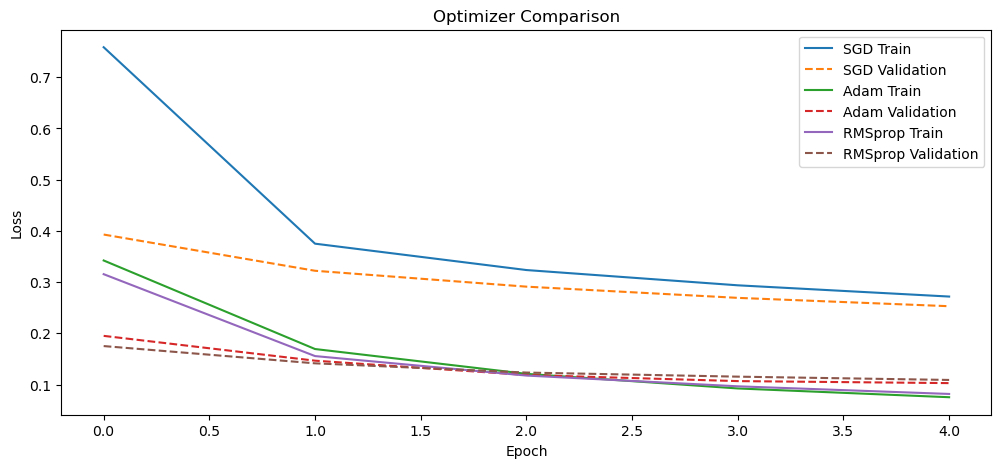

In [6]:
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import SGD, Adam, RMSprop

optimizers = {
    "SGD": SGD(),
    "Adam": Adam(),
    "RMSprop": RMSprop()
}

plt.figure(figsize=(12,5))

for optimizer_name, optimizer in optimizers.items():

    model = Sequential([
        Flatten(input_shape=(28,28)),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        x_train,
        y_train,
        epochs=5,
        validation_split=0.2,
        verbose=0
    )

    plt.plot(
        history.history['loss'],
        label=f"{optimizer_name} Train"
    )

    plt.plot(
        history.history['val_loss'],
        linestyle='--',
        label=f"{optimizer_name} Validation"
    )

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Optimizer Comparison")
plt.legend()
plt.show()

In [11]:
!pip install keras-tuner
!pip install tensorboard

   ---------------------------------------- 0.0/5.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/5.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/5.5 MB ? eta -:--:--
   --- ------------------------------------ 0.5/5.5 MB 1.1 MB/s eta 0:00:05
   --- ------------------------------------ 0.5/5.5 MB 1.1 MB/s eta 0:00:05
   ----- ---------------------------------- 0.8/5.5 MB 783.5 kB/s eta 0:00:07
   ----- ---------------------------------- 0.8/5.5 MB 783.5 kB/s eta 0:00:07
   ----- ---------------------------------- 0.8/5.5 MB 783.5 kB/s eta 0:00:07
   ----- ---------------------------------- 0.8/5.5 MB 783.5 kB/s eta 0:00:07
   ------- -------------------------------- 1.0/5.5 MB 499.5 kB/s eta 0:00:09
   ------- -------------------------------- 1.0/5.5 MB 499.5 kB/s eta 0:00:09
   ------- -------------------------------- 1.0/5.5 MB 499.5 kB/s eta 0:00:09
   ------- -------------------------------- 1.0/5.5 MB 499.5 kB/s eta 0:00:09
   ------- ------

In [12]:
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

def build_model(hp):

    model = Sequential()

    model.add(Flatten(input_shape=(28,28)))

    neurons = hp.Int(
        "neurons",
        min_value=32,
        max_value=256,
        step=32
    )

    model.add(Dense(
        neurons,
        activation='relu'
    ))

    model.add(Dense(
        10,
        activation='softmax'
    ))

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=5,
    directory='tuner_results',
    project_name='mnist_classifier'
)

tuner.search(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=5
)

best_hp = tuner.get_best_hyperparameters(1)[0]

print("Best Number of Neurons:",
      best_hp.get('neurons'))

Trial 8 Complete [00h 00m 35s]
val_accuracy: 0.971916675567627

Best val_accuracy So Far: 0.9773333072662354
Total elapsed time: 00h 04m 15s
Best Number of Neurons: 256


he_normal Final Validation Accuracy: 0.9681666493415833
glorot_uniform Final Validation Accuracy: 0.9679999947547913
random_normal Final Validation Accuracy: 0.9664999842643738


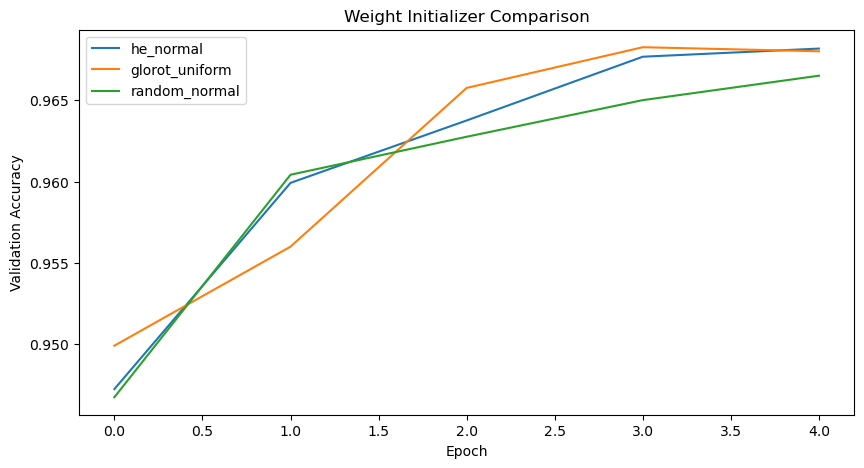

In [13]:
import matplotlib.pyplot as plt

initializers = [
    "he_normal",
    "glorot_uniform",
    "random_normal"
]

plt.figure(figsize=(10,5))

for initializer in initializers:

    model = Sequential([
        Flatten(input_shape=(28,28)),
        Dense(
            64,
            activation='relu',
            kernel_initializer=initializer
        ),
        Dense(
            10,
            activation='softmax'
        )
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        x_train,
        y_train,
        epochs=5,
        validation_split=0.2,
        verbose=0
    )

    plt.plot(
        history.history['val_accuracy'],
        label=initializer
    )

    print(
        initializer,
        "Final Validation Accuracy:",
        history.history['val_accuracy'][-1]
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Weight Initializer Comparison")
plt.legend()
plt.show()